In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv('/Users/drishtant/Documents/Masters/CA/core market data/Project_details_1.3.csv')
project_data = data

/Users/drishtant/Applications/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


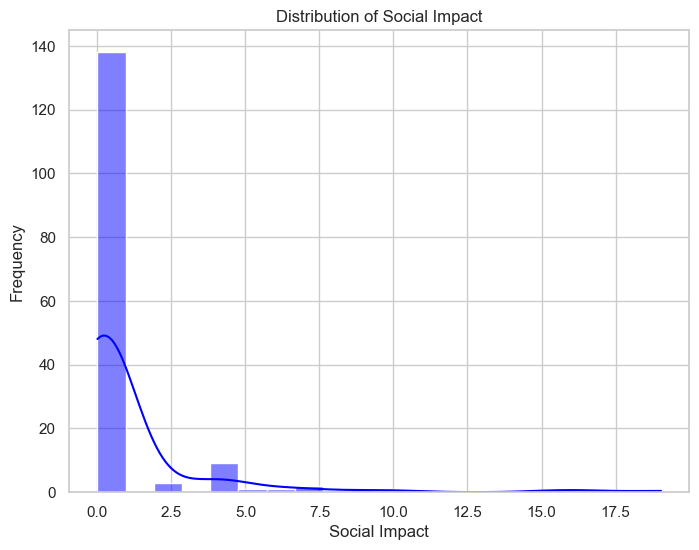

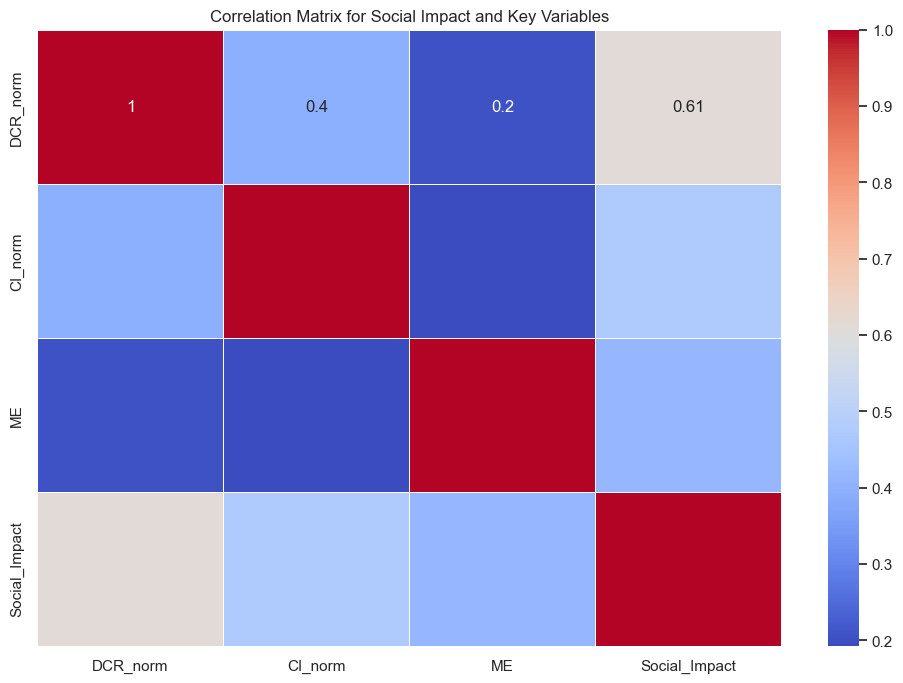

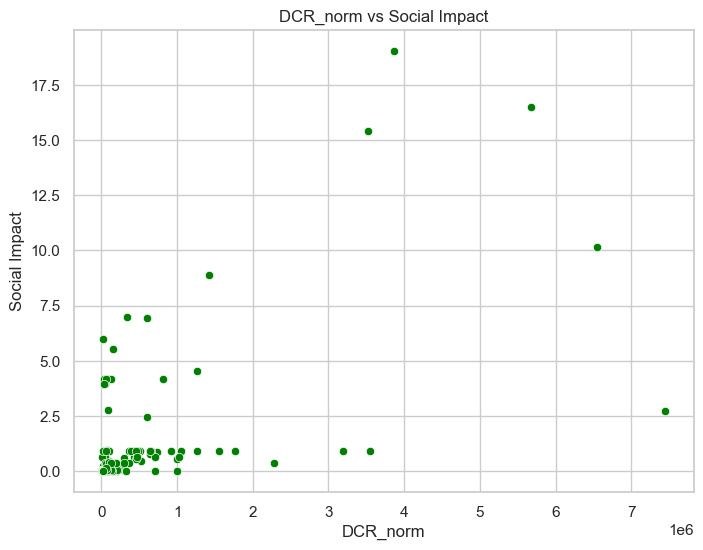

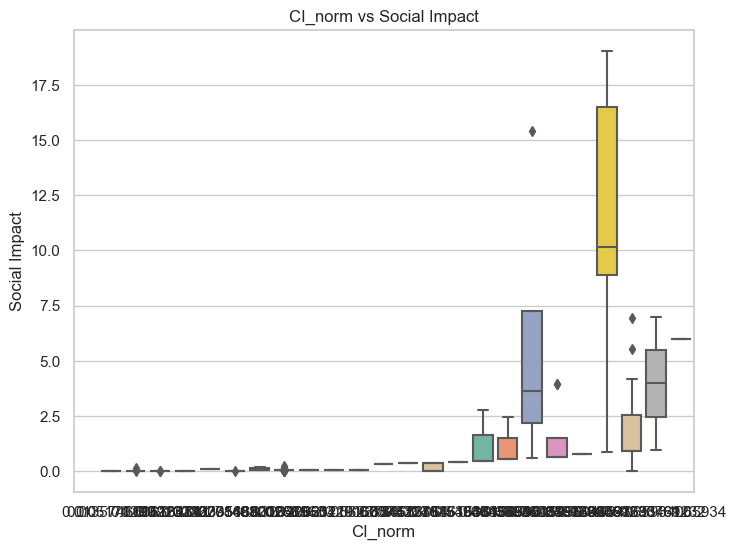

In [3]:
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plot style for better visual aesthetics
sns.set(style="whitegrid")

# Plot 1: Distribution of 'Social_Impact' to understand the target variable distribution
plt.figure(figsize=(8, 6))
sns.histplot(project_data['Social_Impact'], bins=20, kde=True, color='blue')
plt.title('Distribution of Social Impact')
plt.xlabel('Social Impact')
plt.ylabel('Frequency')
plt.show()

# Plot 2: Correlation matrix to see the relationships between numerical variables, especially focusing on Social Impact
plt.figure(figsize=(12, 8))
corr_matrix = project_data[['DCR_norm', 'CI_norm', 'ME', 'Social_Impact']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix for Social Impact and Key Variables')
plt.show()

# Plot 3: Scatter plot of 'DCR_norm' (a project detail feature) vs 'Social_Impact' to visualize the relationship
plt.figure(figsize=(8, 6))
sns.scatterplot(x='DCR_norm', y='Social_Impact', data=project_data, color='green')
plt.title('DCR_norm vs Social Impact')
plt.xlabel('DCR_norm')
plt.ylabel('Social Impact')
plt.show()

# Plot 4: Box plot to analyze how 'CI_norm' (another feature) varies with 'Social_Impact'
plt.figure(figsize=(8, 6))
sns.boxplot(x='CI_norm', y='Social_Impact', data=project_data, palette='Set2')
plt.title('CI_norm vs Social Impact')
plt.xlabel('CI_norm')
plt.ylabel('Social Impact')
plt.show()

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Load the dataset
# file_path = '/mnt/data/Project_details_1.3.csv'
# data = pd.read_csv(file_path)

# Handle missing values for the entire dataset
data.fillna({'Country Status': 'Unknown', 'project_method_type_name': 'Unknown', 'region': 'Unknown'}, 
            inplace=True)
num_imputer = SimpleImputer(strategy='median')

# Creating a count of SDGs each project contributes to
sdg_columns = ['SDG_1', 'SDG_2', 'SDG_3', 'SDG_4', 'SDG_5', 'SDG_6', 'SDG_7', 'SDG_8',
               'SDG_9', 'SDG_10', 'SDG_11', 'SDG_12', 'SDG_13', 'SDG_14', 'SDG_15', 'SDG_16', 'SDG_17']
data['SDG_count'] = data[sdg_columns].sum(axis=1)

# Convert all numerical columns to float and impute missing values
numerical_cols = ['DCR_norm', 'CI_norm', 'ME', 'SDG_count']
for col in numerical_cols:
    data[col] = num_imputer.fit_transform(data[[col]].astype(float))

# Ensure all categorical columns are of type string
categorical_cols = ['Country Status', 'project_method_type_name', 'region']
data[categorical_cols] = data[categorical_cols].astype(str)

# Features and target variable selection
X = data[numerical_cols + categorical_cols]
y = data['Social_Impact'].fillna(value=data['Social_Impact'].median())

# Preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Define the pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', GradientBoostingRegressor(random_state=42))])

# Define the parameters for GridSearchCV
param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
}

# Setup and perform the grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

# Split the dataset and fit the grid search
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
grid_search.fit(X_train, y_train)

# Best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Predictions and evaluation
y_pred_gb = grid_search.predict(X_test)
mse_gb = mean_squared_error(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# Print the results
print("Best Parameters:", best_params)
print("Best MSE (Grid Search):", -best_score)
print("Test MSE:", mse_gb)
print("Test MAE:", mae_gb)
print("Test R²:", r2_gb)


Best Parameters: {'model__learning_rate': 0.2, 'model__n_estimators': 200}
Best MSE (Grid Search): 1.981343119258156
Test MSE: 0.2573748969295724
Test MAE: 0.11688816738540635
Test R²: 0.9691608974879934


In [5]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regressor pipeline setup
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', RandomForestRegressor(random_state=42))])

# Parameters for RF GridSearchCV
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
}

# Setup and perform the grid search for RF
rf_grid_search = GridSearchCV(rf_pipeline, rf_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid_search.fit(X_train, y_train)

# Best parameters, predictions, and evaluation for RF
rf_best_params = rf_grid_search.best_params_
rf_best_score = rf_grid_search.best_score_
y_pred_rf = rf_grid_search.predict(X_test)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("RF Best Parameters:", rf_best_params)
print("RF Best MSE (Grid Search):", -rf_best_score)
print("RF Test MSE:", rf_mse)
print("RF Test MAE:", rf_mae)
print("RF Test R²:", rf_r2)


RF Best Parameters: {'model__max_depth': 10, 'model__n_estimators': 200}
RF Best MSE (Grid Search): 2.113456875508598
RF Test MSE: 0.11499675532940865
RF Test MAE: 0.1021246346085978
RF Test R²: 0.9862208911262927


In [6]:
# Assuming 'data' is the original dataset and 'preprocessor' is already defined
# We prepare X for clustering by excluding 'Social_Impact' directly from the original or preprocessed dataset that includes it

# If 'data' includes all necessary preprocessing except for the final steps:
X_for_clustering = data.drop('Social_Impact', axis=1)  # Dropping the target variable for unsupervised learning

# Applying the preprocessor defined earlier for supervised models
# Ensure this preprocessor doesn't include the final model and is fit for preprocessing the features only
X_clustering = preprocessor.fit_transform(X_for_clustering)

# Proceed with K-Means clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Determine the number of clusters; for demonstration, let's use 3
kmeans = KMeans(n_clusters=3, random_state=42).fit(X_clustering)
labels = kmeans.labels_

# Evaluate the clustering performance using silhouette score
silhouette_avg = silhouette_score(X_clustering, labels)
print("Silhouette Score for K-Means clustering:", silhouette_avg)


Silhouette Score for K-Means clustering: 0.2860469570511661


Random Forest MSE: 0.11499675532940865


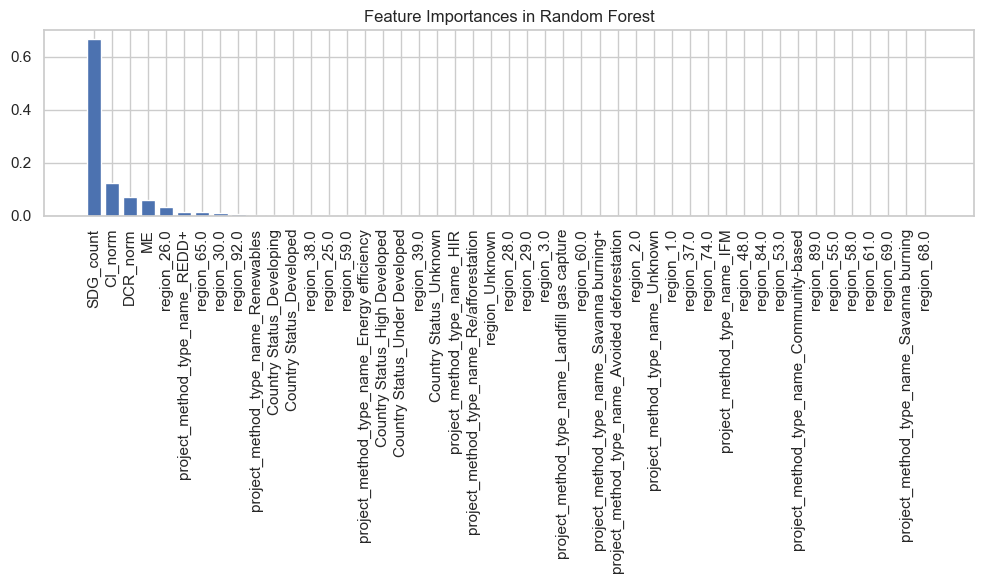

In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Handle missing values for the entire dataset
data.fillna({'Country Status': 'Unknown', 'project_method_type_name': 'Unknown', 'region': 'Unknown'}, inplace=True)

# Create a count of SDGs each project contributes to
sdg_columns = ['SDG_1', 'SDG_2', 'SDG_3', 'SDG_4', 'SDG_5', 'SDG_6', 'SDG_7', 'SDG_8',
               'SDG_9', 'SDG_10', 'SDG_11', 'SDG_12', 'SDG_13', 'SDG_14', 'SDG_15', 'SDG_16', 'SDG_17']
data['SDG_count'] = data[sdg_columns].sum(axis=1)

# Convert all numerical columns to float and impute missing values
numerical_cols = ['DCR_norm', 'CI_norm', 'ME', 'SDG_count']
num_imputer = SimpleImputer(strategy='median')
for col in numerical_cols:
    data[col] = num_imputer.fit_transform(data[[col]].astype(float))

# Ensure all categorical columns are of type string
categorical_cols = ['Country Status', 'project_method_type_name', 'region']
data[categorical_cols] = data[categorical_cols].astype(str)

# Features and target variable selection
X = data[numerical_cols + categorical_cols]
y = data['Social_Impact'].fillna(value=data['Social_Impact'].median())

# Preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),  # Scaling numerical columns
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)  # One-hot encoding for categorical columns
    ])

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess training and test data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Retrieve the names of the new features generated by OneHotEncoder
ohe = preprocessor.named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([numerical_cols, ohe_feature_names])

# Model: Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Hyperparameter grid for tuning
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform GridSearchCV for hyperparameter tuning
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, 
                              scoring='neg_mean_squared_error', cv=5, n_jobs=-1)

# Fit the model (training the RandomForestRegressor with training data)
grid_search_rf.fit(X_train, y_train)

# Get the best model
best_rf = grid_search_rf.best_estimator_

# Make predictions on the test set
y_pred_rf = best_rf.predict(X_test)

# Calculate MSE for Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"Random Forest MSE: {mse_rf}")

# Feature Importance Visualization
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances in Random Forest")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), all_feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

RandomForest MSE: 0.11499675532940865
RandomForest R2: 0.9862208911262927
Ridge MSE: 0.5658768193260393
Ridge R2: 0.9321956669102066
Lasso MSE: 0.6140554830741356
Lasso R2: 0.9264228166130558


/Users/drishtant/Applications/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
40 fits failed out of a total of 80.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/drishtant/Applications/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/drishtant/Applications/anaconda3/lib/python3.11/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/drishtant/Applications/ana

GradientBoosting MSE: 0.3271085896928944
GradientBoosting R2: 0.9608052865666326
XGBoost MSE: 0.41044262336058424
XGBoost R2: 0.9508200594225877
SVR MSE: 0.862288137302088
SVR R2: 0.8966791533347445


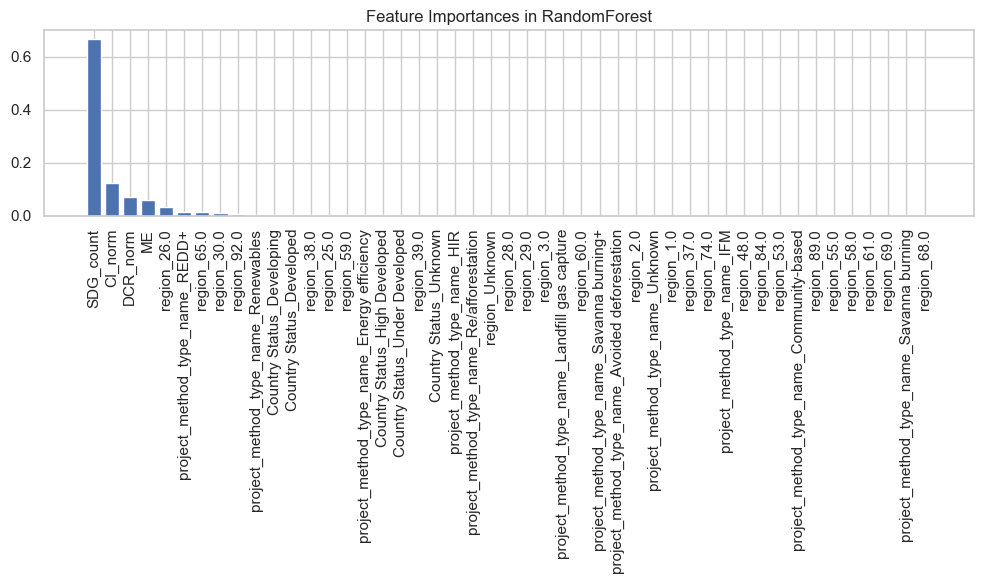

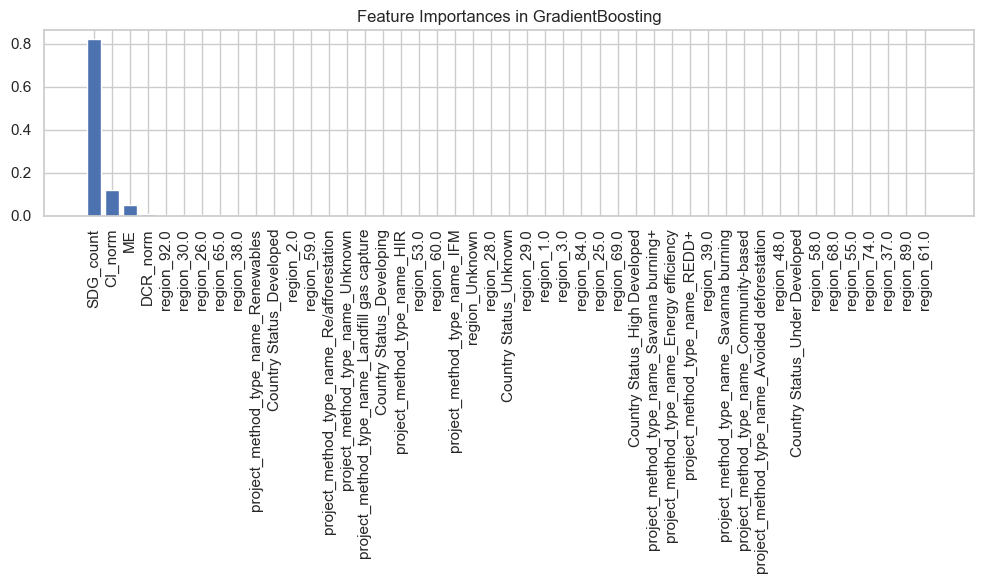

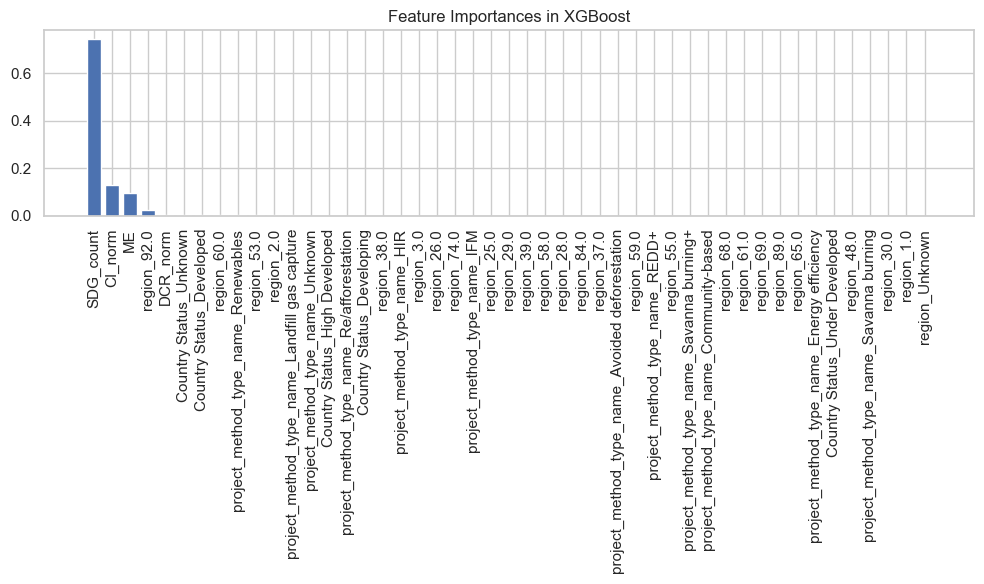

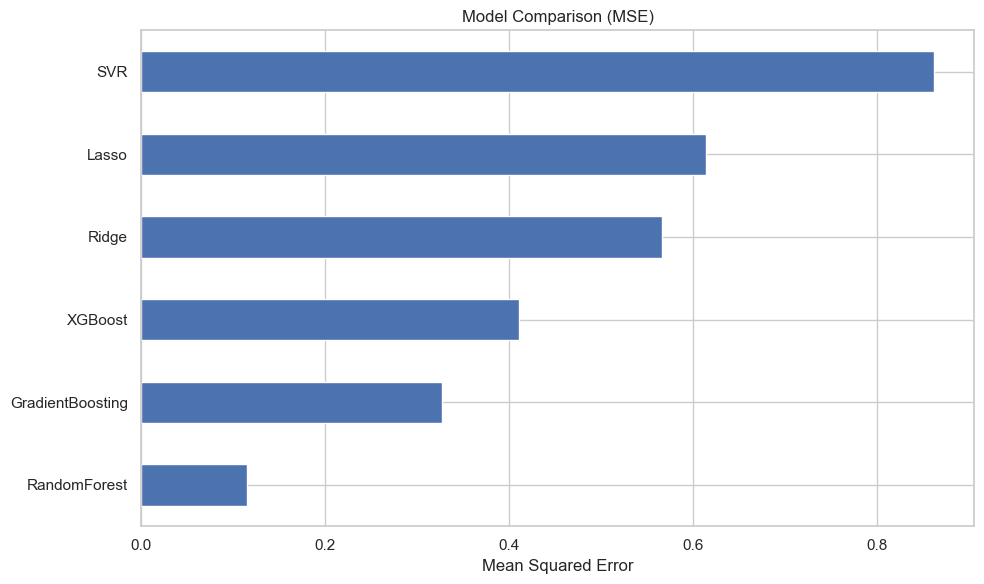

In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.svm import SVR



data = pd.read_csv('/Users/drishtant/Documents/Masters/CA/core market data/Project_details_1.3.csv')

# Data Preprocessing
data.fillna({'Country Status': 'Unknown', 'project_method_type_name': 'Unknown', 'region': 'Unknown'}, inplace=True)

# Creating a count of SDGs each project contributes to
sdg_columns = ['SDG_1', 'SDG_2', 'SDG_3', 'SDG_4', 'SDG_5', 'SDG_6', 'SDG_7', 'SDG_8',
               'SDG_9', 'SDG_10', 'SDG_11', 'SDG_12', 'SDG_13', 'SDG_14', 'SDG_15', 'SDG_16', 'SDG_17']
data['SDG_count'] = data[sdg_columns].sum(axis=1)

# Convert all numerical columns to float and impute missing values
numerical_cols = ['DCR_norm', 'CI_norm', 'ME', 'SDG_count']
num_imputer = SimpleImputer(strategy='median')
for col in numerical_cols:
    data[col] = num_imputer.fit_transform(data[[col]].astype(float))

# Ensure all categorical columns are of type string
categorical_cols = ['Country Status', 'project_method_type_name', 'region']
data[categorical_cols] = data[categorical_cols].astype(str)

# Features and target variable selection
X = data[numerical_cols + categorical_cols]
y = data['Social_Impact'].fillna(value=data['Social_Impact'].median())

# Preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess training and test data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Retrieve the names of the new features generated by OneHotEncoder
ohe = preprocessor.named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([numerical_cols, ohe_feature_names])

# Define a dictionary to store models and their hyperparameters
models = {
    "RandomForest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            'n_estimators': [50, 100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    "Ridge": {
        "model": Ridge(),
        "params": {
            'alpha': [0.01, 0.1, 1.0, 10.0],
            'solver': ['auto', 'svd', 'cholesky', 'lsqr']
        }
    },
    "Lasso": {
        "model": Lasso(),
        "params": {
            'alpha': [0.01, 0.1, 1.0, 10.0],
            'max_iter': [1000, 2000, 3000]
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 10],
            'learning_rate': [0.01, 0.1, 0.2]
        }
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=42),
        "params": {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 10],
            'learning_rate': [0.01, 0.1, 0.2]
        }
    },
    "SVR": {
        "model":  SVR(),
        "params": {
        'C': [0.1, 1.0, 10.0],
        'kernel': ['linear', 'rbf']
    }
    }
   
}


model_results = {}

# Iterate through models, perform GridSearchCV, and store results
for model_name, config in models.items():
    grid_search = GridSearchCV(estimator=config['model'], param_grid=config['params'],
                               scoring='neg_mean_squared_error', cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Get the best model and make predictions
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Calculate MSE and store results
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    model_results[model_name] = {
        "best_model": best_model,
        "mse": mse,
        "r2" : r2
    
    }
    
    print(f"{model_name} MSE: {mse}")
    print(f"{model_name} R2: {r2}")

# Visualization of Feature Importances (for models that support it)
for model_name in model_results:
    if model_name in ['RandomForest', 'GradientBoosting', 'XGBoost']:
        best_model = model_results[model_name]["best_model"]
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[::-1]
        
        plt.figure(figsize=(10, 6))
        plt.title(f"Feature Importances in {model_name}")
        plt.bar(range(X_train.shape[1]), importances[indices], align="center")
        plt.xticks(range(X_train.shape[1]), all_feature_names[indices], rotation=90)
        plt.tight_layout()
        plt.show()

# Comparing Model Performance
mse_values = {model_name: result['mse'] for model_name, result in model_results.items()}
mse_series = pd.Series(mse_values)

mse_series.sort_values(ascending=True).plot(kind='barh', title="Model Comparison (MSE)", figsize=(10, 6))
plt.xlabel("Mean Squared Error")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

# Make sure X is still a DataFrame when passed to ColumnTransformer
X = data[numerical_cols + categorical_cols]

# Split dataset into training and testing as DataFrame
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Fit the preprocessor on X_train and transform both X_train and X_test
X_train_transformed = preprocessor.fit_transform(X_train)  # Fit on training data
X_test_transformed = preprocessor.transform(X_test)  # Transform test data

# If the transformed data is sparse, convert to dense as SHAP requires dense input
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()

# Extract feature names after OneHotEncoding
ohe = preprocessor.named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([numerical_cols, ohe_feature_names])

# Now we can use SHAP to explain the predictions
for model_name in ['RandomForest', 'GradientBoosting', 'XGBoost']:
    best_model = model_results[model_name]['best_model']
    
    # SHAP Tree Explainer for tree-based models
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_transformed)
    
    # Summary plot
    shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names)
    
    # Dependence plot for the first feature
    shap.dependence_plot(0, shap_values, X_test_transformed, feature_names=all_feature_names)
